# **Classificador de fator de risco do Câncer do Colo do Útero**

Este trabahlo tem como objetivo classificar o fator de risco do câncer do colo do útero, e o dataset utilizado foi coletado no hospital universitário de Caracas na Venezuela e abrange informações demográficas, habitos, registros médicos históricos e contém 4 targets, são eles Hinselmann, Schiller, citology e Biopsy, todos são exames, sendo que a Biopsy é o mais representativa.

## **Atributos**

* (int) Age
* (int) Number of sexual partners
* (int) First sexual intercourse (age)
* (int) Num of pregnancies
* (bool) Smokes
* (bool) Smokes (years)
* (bool) Smokes (packs/year)
* (bool) Hormonal Contraceptives
* (int) Hormonal Contraceptives (years)
* (bool) IUD
* (int) IUD (years)
* (bool) STDs
* (int) STDs (number)
* (bool) STDs:condylomatosis
* (bool) STDs:cervical condylomatosis
* (bool) STDs:vaginal condylomatosis
* (bool) STDs:vulvo-perineal condylomatosis
* (bool) STDs:syphilis
* (bool) STDs:pelvic inflammatory disease
* (bool) STDs:genital herpes
* (bool) STDs:molluscum contagiosum
* (bool) STDs:AIDS
* (bool) STDs:HIV
* (bool) STDs:Hepatitis B
* (bool) STDs:HPV
* (int) STDs: Number of diagnosis
* (int) STDs: Time since first diagnosis
* (int) STDs: Time since last diagnosis
* **(bool) Dx:Cancer (Diagnóstico prévio, será removida)**
* **(bool) Dx:CIN (Diagnóstico prévio, será removida)**
* **(bool) Dx:HPV (Diagnóstico prévio, será removida)**
* **(bool) Dx (Diagnóstico prévio, será removida)**
* (bool) Hinselmann: target variable
* (bool) Schiller: target variable
* (bool) Citology: target variable
* **(bool) Biopsy: target variable principal**

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

%matplotlib inline

In [32]:
dataset = pd.read_csv("risk_factors_cervical_cancer.csv")
pd.set_option('display.max_columns', None)

dataset.shape

(858, 36)

In [33]:
dataset.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,?,?,0,0,0,0,0,0,0,0


Algumas pacientes decidiram não responder todas questões por preocupações com a privacidade, por isso existem campos inválidos, esses campos foram preenchidos com interrogação. A leitura do dataset será realizada agora com a substituição das interrogações por nulos para facilitar a análise.

In [34]:
dataset = pd.read_csv("risk_factors_cervical_cancer.csv", na_values='?')
dataset.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


## **Tratamento dos atributos nulos**

É possível notar que existem muitos nulos, isso acontece porque nesse dataset houveram questões que não foram respondidas pelos paciente e esse fato dos pacientes terem se recusado a responder as questões pode ser uma informação valiosa na análise estatística, então os nulos serão tratados com a média e será aplicado o **indicador de missing** que é uma nova coluna capaz de representar se a questão foi respondida ou não.

A escolha da média faz sentido se associar ela às novas colunas, então o modelo pode aprender e entender esse comportamento.

In [35]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-null    floa

* É possível notar que a quantidade de questões respondidas é igual para atributos semelhantes, por exemplo as STDs com 753.

* As colunas **STDs: Time since first diagnosis** e **STDs: Time since last diagnosis** tem mais de 90% de de valores faltantes.

In [36]:
colunas = dataset.columns.tolist()

def tratar_missing_com_indicador(dataset):
    dt = dataset.copy()

    colunas = dt.columns.tolist()

    for col in colunas:
        if dt[col].isnull().any():

            # Criar coluna indicador (1 = respondeu, 0 = não respondeu)
            nome_nova_coluna = f"{col}_preenchido"
            dt[nome_nova_coluna] = dt[col].notnull().astype(int)

            # Calcular média
            media = dt[col].mean()

            # Preencher nulos
            dt[col] = dt[col].fillna(media)

    return dt

dataset = tratar_missing_com_indicador(dataset)

In [37]:
dataset.isnull().sum()

Age                                            0
Number of sexual partners                      0
First sexual intercourse                       0
Num of pregnancies                             0
Smokes                                         0
                                              ..
STDs:HIV_preenchido                            0
STDs:Hepatitis B_preenchido                    0
STDs:HPV_preenchido                            0
STDs: Time since first diagnosis_preenchido    0
STDs: Time since last diagnosis_preenchido     0
Length: 62, dtype: int64

Como comentado anteriormente sobre a quantidade de questões respondias, será realizada uma contagem para verificar se existem grupos.

In [38]:
colunas_preenchido = [col for col in dataset.columns if '_preenchido' in col]
for col in colunas_preenchido:
    print(dataset[col].value_counts(normalize=True))
    print()

Number of sexual partners_preenchido
1    0.969697
0    0.030303
Name: proportion, dtype: float64

First sexual intercourse_preenchido
1    0.991841
0    0.008159
Name: proportion, dtype: float64

Num of pregnancies_preenchido
1    0.934732
0    0.065268
Name: proportion, dtype: float64

Smokes_preenchido
1    0.984848
0    0.015152
Name: proportion, dtype: float64

Smokes (years)_preenchido
1    0.984848
0    0.015152
Name: proportion, dtype: float64

Smokes (packs/year)_preenchido
1    0.984848
0    0.015152
Name: proportion, dtype: float64

Hormonal Contraceptives_preenchido
1    0.874126
0    0.125874
Name: proportion, dtype: float64

Hormonal Contraceptives (years)_preenchido
1    0.874126
0    0.125874
Name: proportion, dtype: float64

IUD_preenchido
1    0.863636
0    0.136364
Name: proportion, dtype: float64

IUD (years)_preenchido
1    0.863636
0    0.136364
Name: proportion, dtype: float64

STDs_preenchido
1    0.877622
0    0.122378
Name: proportion, dtype: float64

STDs (nu

**É possível notar que existem alguns grupos** porque os valores são iguais:

* Grupo STDs 0 = 0.877622
* Smokes 1 = 0.984848  
* Hormonal Contraceptives 1 = 0.874126
* IUD 1 = 0.863636
* First and last Diagnosis 0 = 0.917249

Será feito o agrupamento no dataset

In [39]:
def agrupar_colunas_preenchido(df, sufixo='_preenchido', novo_sufixo='_respondido'):
    df = df.copy()

    # 1. Selecionar colunas com sufixo
    colunas = [col for col in df.columns if sufixo in col]

    # 2. Agrupar colunas idênticas
    grupos = {}

    for col in colunas:
        valores = tuple(df[col].values)

        if valores in grupos:
            grupos[valores].append(col)
        else:
            grupos[valores] = [col]

    novas_colunas = []

    # 3. Criar novas colunas e remover redundantes
    for grupo in grupos.values():

        if len(grupo) > 1:
            nome_base = grupo[0].replace(sufixo, '')
            nova_coluna = f"{nome_base}{novo_sufixo}"

            df[nova_coluna] = df[grupo[0]]
            df.drop(columns=grupo, inplace=True)

            novas_colunas.append(nova_coluna)

        else:
            col = grupo[0]
            novo_nome = col.replace(sufixo, novo_sufixo)

            df.rename(columns={col: novo_nome}, inplace=True)
            novas_colunas.append(novo_nome)

    return df

dataset = agrupar_colunas_preenchido(dataset)

In [40]:
dataset.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy,Number of sexual partners_respondido,First sexual intercourse_respondido,Num of pregnancies_respondido,Smokes_respondido,Hormonal Contraceptives_respondido,IUD_respondido,STDs_respondido,STDs: Time since first diagnosis_respondido
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.0,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.0,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,2.527644,16.995300,2.275561,0.145562,1.219721,0.453144,0.641333,2.256419,0.112011,0.514804,0.104914,0.176627,0.058433,0.0,0.005312,0.057105,0.023904,0.001328,0.001328,0.001328,0.0,0.023904,0.001328,0.002656,0.087413,6.140845,5.816901,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103,0.969697,0.991841,0.934732,0.984848,0.874126,0.863636,0.877622,0.082751
std,8.497948,1.642267,2.791883,1.399325,0.350189,4.057885,2.209657,0.448671,3.519082,0.293260,1.805585,0.287247,0.526440,0.219868,0.0,0.068137,0.217508,0.143183,0.034137,0.034137,0.034137,0.0,0.143183,0.034137,0.048244,0.302545,1.684784,1.644843,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078,0.171520,0.090008,0.247142,0.122227,0.331901,0.343374,0.327913,0.275666
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,6.140845,5.816901,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,6.140845,5.816901,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,2.256419,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,6.140845,5.816901,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,19.000000,1.000000,4.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,3.000000,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000

## **Interpretação das estatísticas**

* Pacientes jovens, possível assimetria (tem alguns mais velhos puxando a média).
* A maioria tem poucos parceiros, existem outliers fortes.
* Primeira relação sexual com média de 17 anos, mínimo com 10, é um erro ou caso real?
* Gravidez com média de 2, mas com outliers.
* Poucos fumantes.
* Mais da metade usa contraceptivos hormonais com tempo de uso muito variável.
* As DSTs são raras, quase sempre zero.
* As targets também são raras, logo temos uma dataset desbalanceado.
* As colunas **STDs:AIDS** e **STDs:cervical condylomatosis** só tem um valor para todos os pacientes, não tem variabilidade, então não servem.
* Faz sentido manter os atributos **STDs: Time since first diagnosis** e **STDs:
Time since last diagnosis** considerando também que o dataset é pequeno.



In [41]:
dataset['STDs:AIDS'].value_counts()

STDs:AIDS
0.0    858
Name: count, dtype: int64

In [42]:
dataset['STDs:cervical condylomatosis'].value_counts()

STDs:cervical condylomatosis
0.0    858
Name: count, dtype: int64

Comprovado que nenhum dos pacientes teve essas DSTs então podem ser removidas do dataset.

In [43]:
dataset.drop(['STDs:AIDS', 'STDs:cervical condylomatosis'], axis=1, inplace=True)

Agora serão realizadas algumas análises com a utilização de gráficos, a começar pelos atributos demográficos e comportamentais.

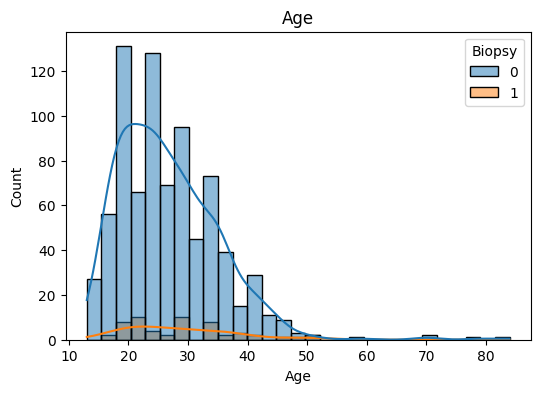

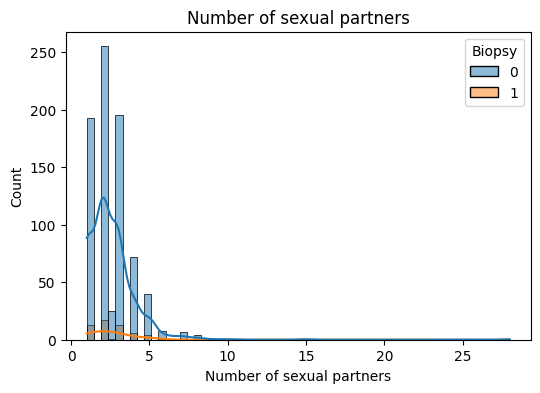

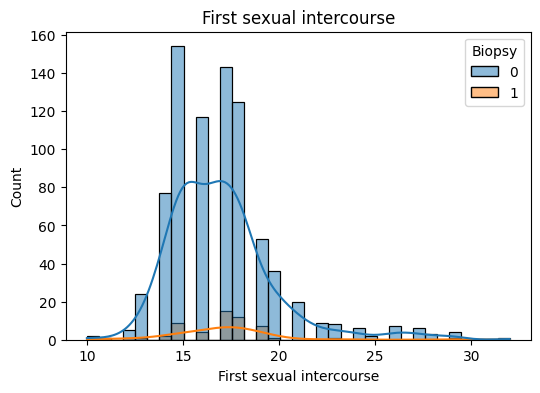

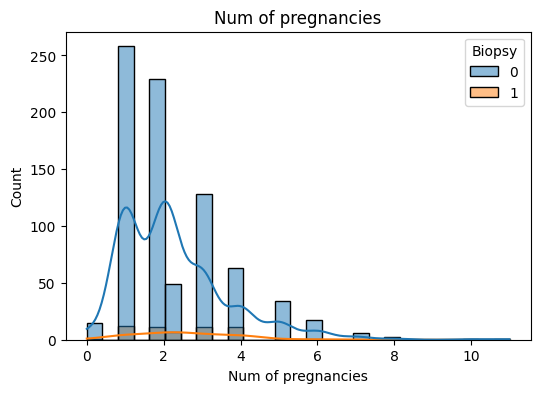

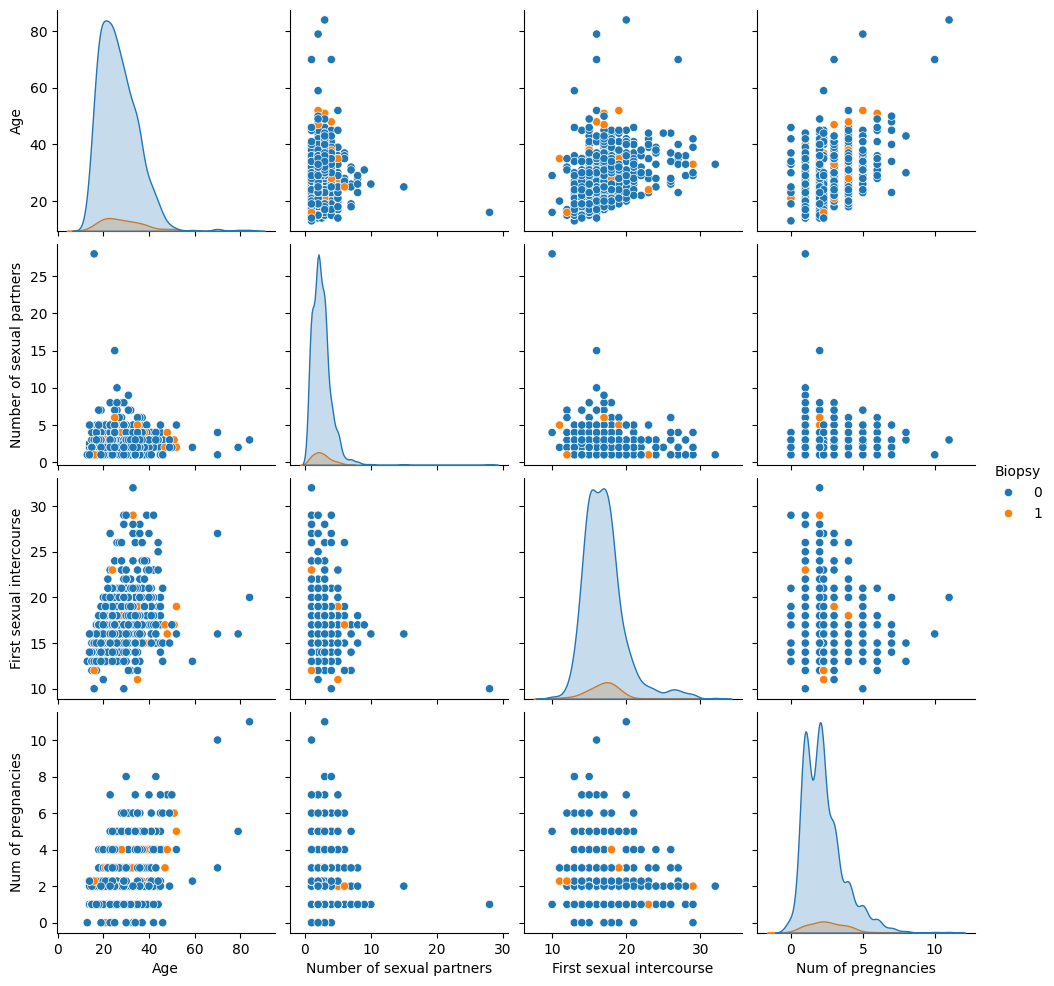

In [44]:
cols = [
    'Age',
    'Number of sexual partners',
    'First sexual intercourse',
    'Num of pregnancies'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sb.histplot(data=dataset, x=col, hue='Biopsy', kde=True)
    plt.title(col)
    plt.show()

sb.pairplot(dataset[cols + ['Biopsy']], hue='Biopsy')
plt.show()

Pode-se concluir com a análise dos gŕaficos que a correlção desses atributos é fraca, pois não existe uma separação clara das pacientes com e sem cancer.

Remover os outliers não parece ser uma alternativa adequada já que no histograma da idade é possível ver que tem uma paciente com cancer aos 70 anos, além de o dataset ser pequeno.

Pode ser realizada a discretização ou transformação desses atributos, mas como são poucos dados, pode piorar ou não trazer resultados.

In [45]:
def discretizar_demograficos_comportamentais(df):
    df = df.copy()

    config = {
        'Age': [0, 20, 30, 40, 100],
        'Number of sexual partners': [0, 2, 5, 10, 50],
        'First sexual intercourse': [0, 14, 17, 20, 40],
        'Num of pregnancies': [-1, 0, 2, 5, 20],
    }

    for col, bins in config.items():
        df[col] = pd.cut(df[col], bins=bins, labels=False, include_lowest=True)

    return df

def transformar_demograficos_comportamentais(df):
    df = df.copy()

    cols = [
        'Age',
        'Number of sexual partners',
        'First sexual intercourse',
        'Num of pregnancies',
    ]

    # Transformação log (só onde faz sentido)
    for col in cols:
        if col in df.columns and (df[col] >= 0).all():
            df[col] = np.log1p(df[col])

    return df

# dataset = discretizar_demograficos_comportamentais(dataset)
# dataset = transformar_demograficos_comportamentais(dataset)
# Testei os dois, a discretização piora e a transformação não dá resultados, podemos fazer o pipeline testando os dois como demonstração

Agora serão realizadas algumas análises com a utilização de gráficos para os atributos relacionados ao tabagismo.

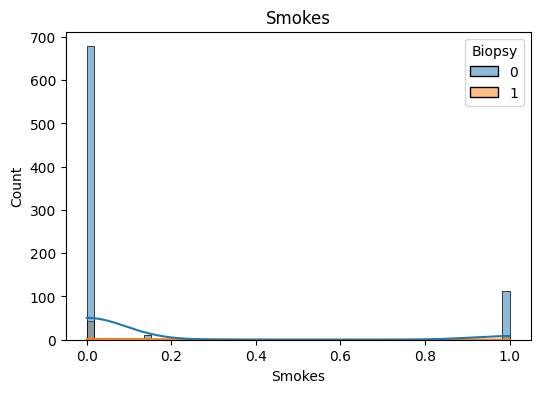

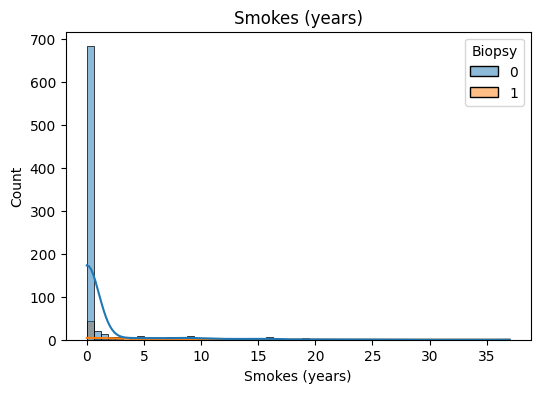

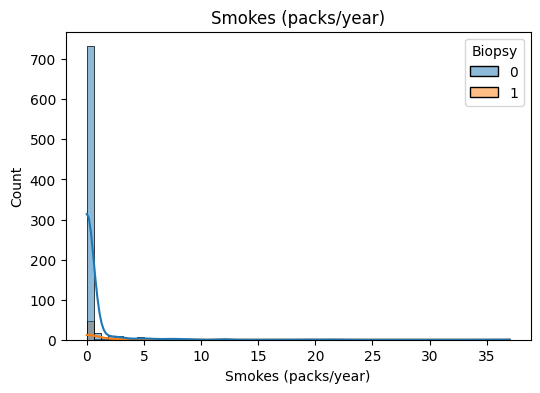

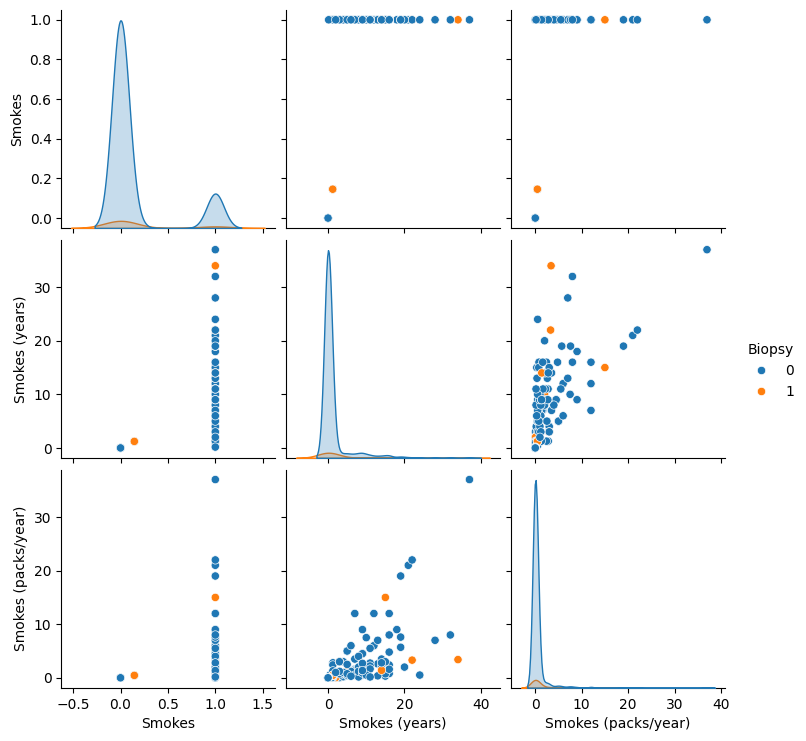

In [46]:
cols = [
    'Smokes',
    'Smokes (years)',
    'Smokes (packs/year)'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sb.histplot(data=dataset, x=col, hue='Biopsy', kde=True)
    plt.title(col)
    plt.show()

sb.pairplot(dataset[cols + ['Biopsy']], hue='Biopsy')
plt.show()

A correlação para fumantes também é fraca, não há separação clara das classes, pode ser realizado o tratamento para reduzir redundância criando um novo atributo, mas antes é necessário garantir a consistência, se não fuma (zero), então faz sentido as outras serem zero também.

In [47]:

def reduzir_redundancia_smokes(df):
    df = df.copy()

    df.loc[df['Smokes'] == 0, ['Smokes (years)', 'Smokes (packs/year)']] = 0

    # combinar
    df['smoke_year_packs'] = df['Smokes (years)'] * df['Smokes (packs/year)']

    # remover redundantes
    df.drop(columns=['Smokes (years)', 'Smokes (packs/year)'], inplace=True)

    return df

dataset = reduzir_redundancia_smokes(dataset)
#  Não houve melhora na classificação fazendo esse tratamento

Agora serão realizadas algumas análises com a utilização de gráficos para os atributos relacionados ao uso de contraceptivos.

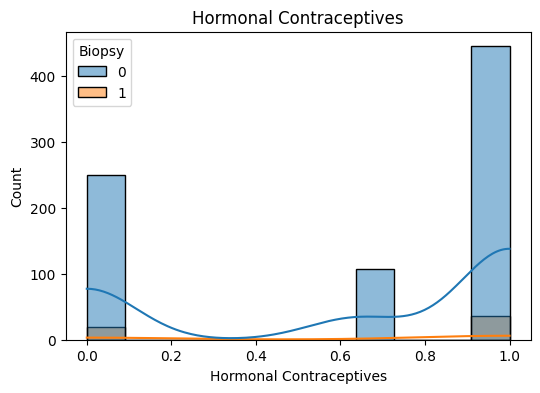

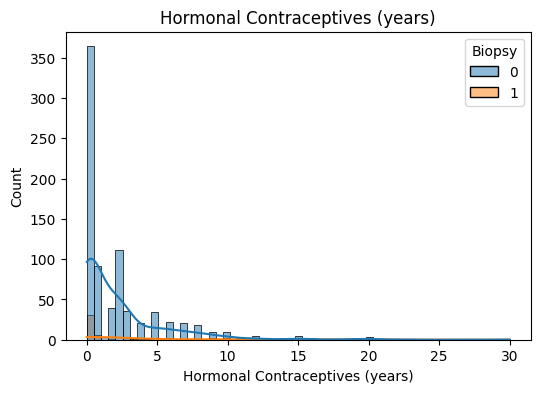

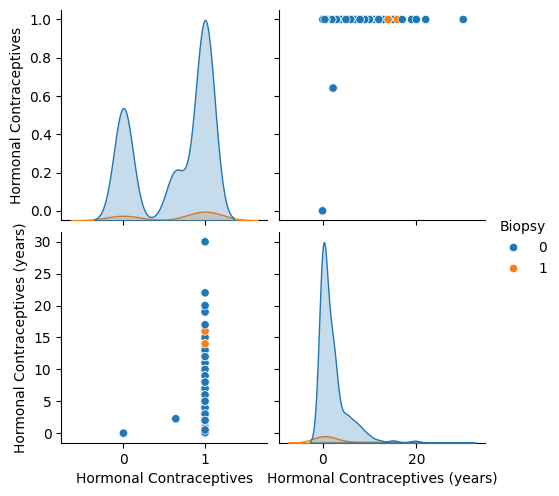

In [48]:
cols = [
    'Hormonal Contraceptives',
    'Hormonal Contraceptives (years)'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sb.histplot(data=dataset, x=col, hue='Biopsy', kde=True)
    plt.title(col)
    plt.show()

sb.pairplot(dataset[cols + ['Biopsy']], hue='Biopsy')
plt.show()

Existe uma relação não linear entre anos de uso de contraceptivos que fica na faixa de 5 a 15 anos, ou seja, o risco não aumenta conforme a quantidade de anos. Algumas features novas podem ser criadas a partir desses atributos.

In [49]:
def transformar_contraceptivos(df):
    df = df.copy()

    df.loc[dataset['Hormonal Contraceptives'] == 0, 'Hormonal Contraceptives (years)'] = 0

    col_bin = 'Hormonal Contraceptives'
    col_years = 'Hormonal Contraceptives (years)'

    if {col_bin, col_years}.issubset(df.columns):

        # Flag de risco intermediário
        df['contraceptive_mid_risk'] = (
            (df[col_bin] == 1) &
            (df[col_years].between(3, 15))
        ).astype(int)

        # Interação (exposição)
        df['contraceptive_exposure'] = df[col_bin] * df[col_years]

    return df

dataset = transformar_contraceptivos(dataset)
# Também não altera a classificação

Agora serão plotados os gráficos de alguns atributos de DSTs, no entanto como são muitas DSTs e os casos são raros, os gráficos terão somente o HPV que é a DST que tem mais relação com cancer segundo a medicina.

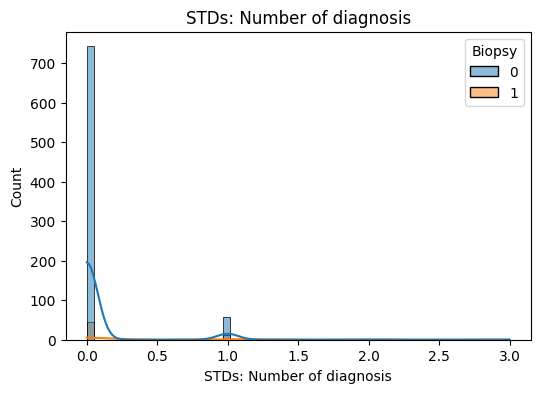

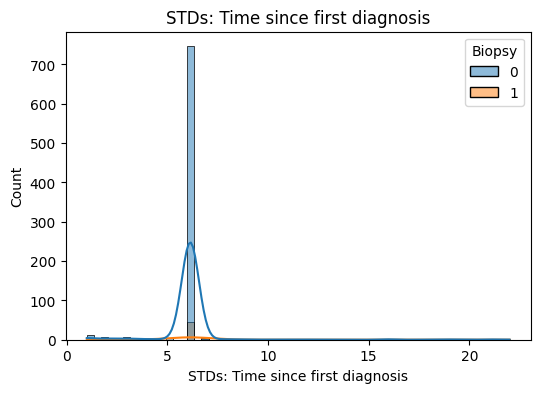

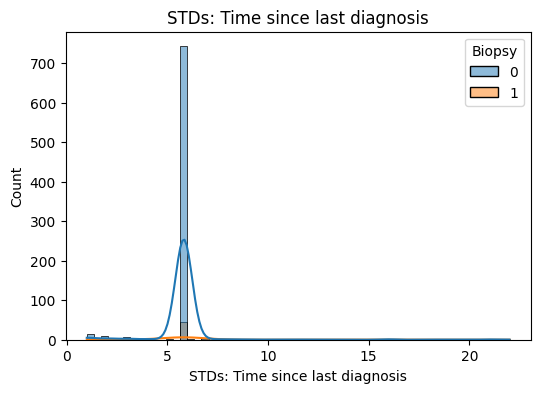

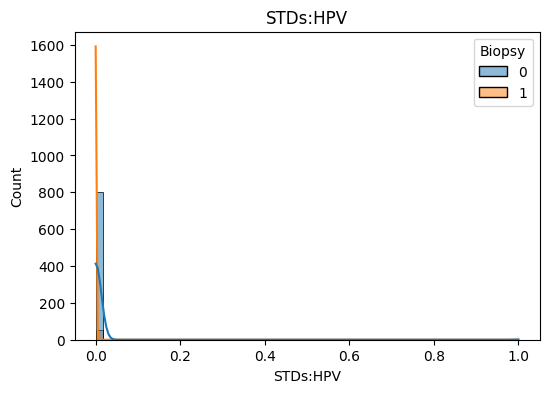

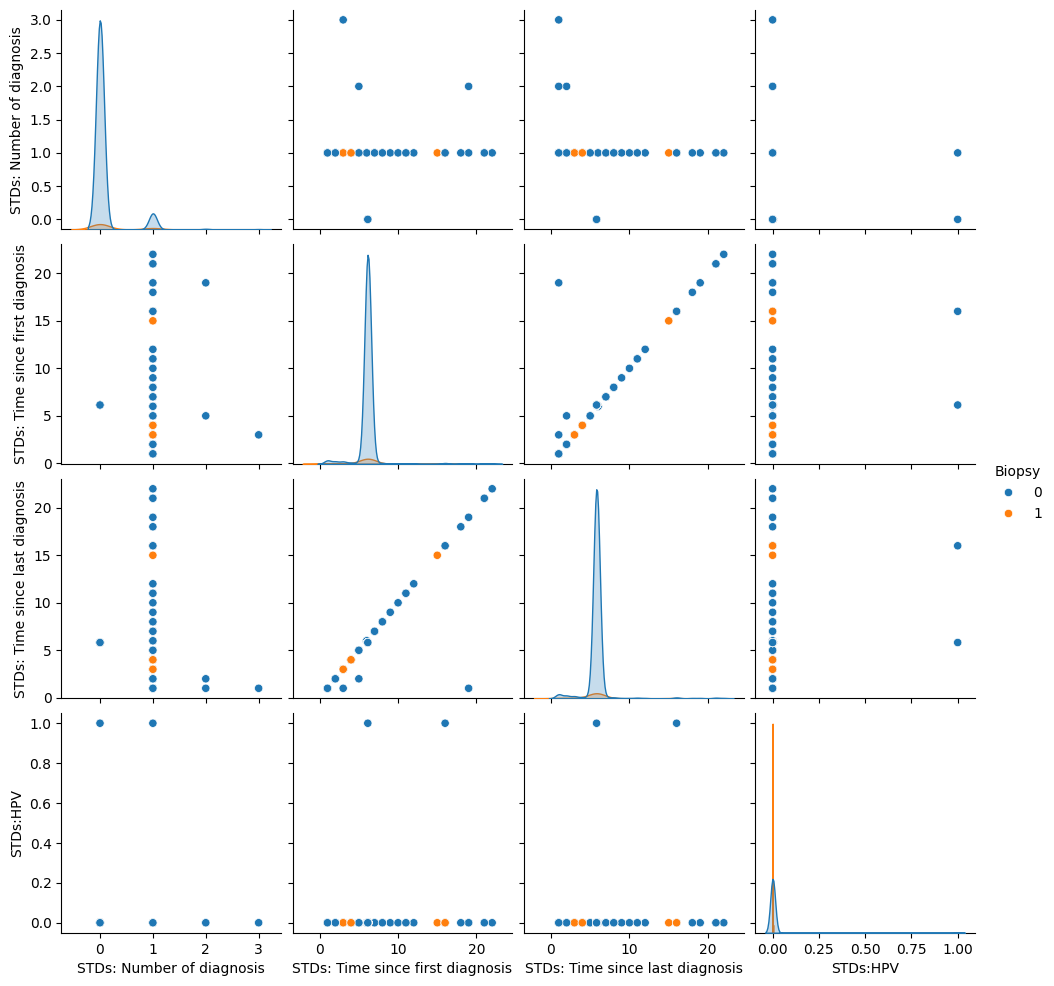

In [50]:
cols = [
    'STDs: Number of diagnosis',
    'STDs: Time since first diagnosis',
    'STDs: Time since last diagnosis',
    'STDs:HPV'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sb.histplot(data=dataset, x=col, hue='Biopsy', kde=True)
    plt.title(col)
    plt.show()

sb.pairplot(dataset[cols + ['Biopsy']], hue='Biopsy')
plt.show()

**STDs: Time since first diagnosis** e **STDs: Time since last diagnosis** formam uma reta diagonal, isso mostra que elas são redundantes, então uma delas pode ser removida.

In [51]:
dataset.drop(['STDs: Time since first diagnosis'], axis=1, inplace=True)

Com a análise dos gráficos foi possível perceber que os atributos isoladamente têm pouca correlação com a classe, mas será que se conbinálos seria possível criar uma correlação forte?

In [52]:
def criar_atributos_estrategicos(df):
    df = df.copy()

    # RISCO SEXUAL (comportamento + idade)
    if {'Number of sexual partners', 'Age'}.issubset(df.columns):
        df['sexual_risk'] = df['Number of sexual partners'] / (df['Age'] + 1)

    if 'First sexual intercourse' in df.columns:
        df['early_sex'] = (df['First sexual intercourse'] < 16).astype(int)

    # TABAGISMO (fraco isolado)
    if 'smoke_year_packs' in df.columns:

        if 'Age' in df.columns:
            df['smoke_age_risk'] = df['smoke_year_packs'] / (df['Age'] + 1)

    # STDs (raras → simplificar)
    if 'STDs (number)' in df.columns:
        df['has_std'] = (df['STDs (number)'] > 0).astype(int)

        if 'Age' in df.columns:
            df['std_age_risk'] = df['STDs (number)'] / (df['Age'] + 1)


    # RISCO COMBINADO
    if {
        'Number of sexual partners',
        'Hormonal Contraceptives',
        'STDs (number)'
    }.issubset(df.columns):

        df['combined_risk'] = (
            df['Number of sexual partners'] *
            (df['Hormonal Contraceptives'] + 1) *
            (df['STDs (number)'] + 1)
        )

    return df

dataset = criar_atributos_estrategicos(dataset)
# fiz uns teste e não mudou nada.

In [53]:
dataset = pd.read_csv("risk_factors_cervical_cancer.csv", na_values='?')

pipeline = Pipeline([
    ('missing', FunctionTransformer(tratar_missing_com_indicador)),
    ('agrupar', FunctionTransformer(agrupar_colunas_preenchido)),
    ('smokes', FunctionTransformer(reduzir_redundancia_smokes)),
    # ('discretizar_demo_comp', FunctionTransformer(discretizar_demograficos_comportamentais)), # Ao discretizar perdeu-se informação útil e piorou a classificação
    ('transformar_demo_comp', FunctionTransformer(transformar_demograficos_comportamentais)),
    ('contraceptivos', FunctionTransformer(transformar_contraceptivos)),
    ('features', FunctionTransformer(criar_atributos_estrategicos)),
    ('model', RandomForestClassifier(class_weight={0:1, 1:14},random_state=42))
])

targets = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']
cols_remover = ['Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']

X = dataset.drop(columns=targets + cols_remover)
y = dataset['Biopsy']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42)

pipeline.fit(X_train, y_train)

y_pred_baseline = pipeline.predict(X_test)

print("===== BASELINE =====")
print(classification_report(y_test, y_pred_baseline))

# MODELOS AUXILIARES (source tasks)
model_hinselmann = RandomForestClassifier(class_weight={0: 1, 1: 14}, random_state=42)
model_schiller = RandomForestClassifier(class_weight={0: 1, 1: 14}, random_state=42)
model_citology = RandomForestClassifier(class_weight={0: 1, 1: 14}, random_state=42)

# Treinar usando os mesmos dados de treino
model_hinselmann.fit(X_train, dataset.loc[X_train.index, 'Hinselmann'])
model_schiller.fit(X_train, dataset.loc[X_train.index, 'Schiller'])
model_citology.fit(X_train, dataset.loc[X_train.index, 'Citology'])

# GERAR FEATURES DE TRANSFER LEARNING
X_train_tl = X_train.copy()
X_test_tl = X_test.copy()

# usar probabilidades (mais informativo)
X_train_tl['hinselmann_pred'] = model_hinselmann.predict_proba(X_train)[:, 1]
X_train_tl['schiller_pred'] = model_schiller.predict_proba(X_train)[:, 1]
X_train_tl['citology_pred'] = model_citology.predict_proba(X_train)[:, 1]

X_test_tl['hinselmann_pred'] = model_hinselmann.predict_proba(X_test)[:, 1]
X_test_tl['schiller_pred'] = model_schiller.predict_proba(X_test)[:, 1]
X_test_tl['citology_pred'] = model_citology.predict_proba(X_test)[:, 1]

# MODELO FINAL (com transfer learning)
model_final = RandomForestClassifier(
    class_weight={0: 1, 1: 14},
    random_state=42
)

model_final.fit(X_train_tl, y_train)

y_pred_tl = model_final.predict(X_test_tl)

print("\n===== TRANSFER LEARNING =====")
print(classification_report(y_test, y_pred_tl))

===== BASELINE =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       161
           1       0.50      0.09      0.15        11

    accuracy                           0.94       172
   macro avg       0.72      0.54      0.56       172
weighted avg       0.91      0.94      0.91       172


===== TRANSFER LEARNING =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       161
           1       0.50      0.09      0.15        11

    accuracy                           0.94       172
   macro avg       0.72      0.54      0.56       172
weighted avg       0.91      0.94      0.91       172

